In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Markov Chains

Given $N$ discrete states and the probability function $p(X_i|X_j)$ that describes the probability of transitioning to state $X_i$ given that the current state is $X_j$, we can create a transition matrix $M$ by placing the probabilities for each state in the columns. 
$$
    M = \begin{bmatrix}
        p(X_1|X_1) & p(X_1|X_2) & p(X_1|X_3) \\
        p(X_2|X_1) & p(X_2|X_2) & p(X_2|X_3) \\
        p(X_3|X_1) & p(X_3|X_2) & p(X_3|X_3)
    \end{bmatrix}
$$
Important is that the columns must sum to 1, i.e., $\sum_{i=1}^N p(X_i|X_j) = 1$.

If the initial state $\mathbf{s}_0$ is $[1, 0, 0]^T$, then the state after transitioning once becomes
$$
    \mathbf{s}_1 = M \mathbf{s}_0
$$

An interesting question is then what the state $\mathbf{s}_k$ is after transitioning for $k$ times, which can be calculated as
$$
    \mathbf{s}_k = \underbrace{M M \dots M}_{k \text{ times}} \mathbf{s}_0
$$

## Simple example

In [ ]:
M = np.array([
    [0.2, 0.4, 0.3], # p(X_1 | X_j)
    [0.5, 0.4, 0.3], # p(X_2 | X_j)
    [0.3, 0.2, 0.4]  # p(X_3 | X_j)
])

# initial state is X_1
s0 = np.array([1, 0, 0])

# transition diffused s0 
M @ s0

array([0.2, 0.5, 0.3])

In [53]:
s = s0
states = []
k = 20

# transition k times
for _ in range(k):
    states.append(s)
    s = M @ s

states

[array([1, 0, 0]),
 array([0.2, 0.5, 0.3]),
 array([0.33, 0.39, 0.28]),
 array([0.306, 0.405, 0.289]),
 array([0.3099, 0.4017, 0.2884]),
 array([0.30918, 0.40215, 0.28867]),
 array([0.309297, 0.402051, 0.288652]),
 array([0.3092754, 0.4020645, 0.2886601]),
 array([0.30927891, 0.40206153, 0.28865956]),
 array([0.30927826, 0.40206194, 0.2886598 ]),
 array([0.30927837, 0.40206185, 0.28865979]),
 array([0.30927835, 0.40206186, 0.28865979]),
 array([0.30927835, 0.40206186, 0.28865979]),
 array([0.30927835, 0.40206186, 0.28865979]),
 array([0.30927835, 0.40206186, 0.28865979]),
 array([0.30927835, 0.40206186, 0.28865979]),
 array([0.30927835, 0.40206186, 0.28865979]),
 array([0.30927835, 0.40206186, 0.28865979]),
 array([0.30927835, 0.40206186, 0.28865979]),
 array([0.30927835, 0.40206186, 0.28865979])]

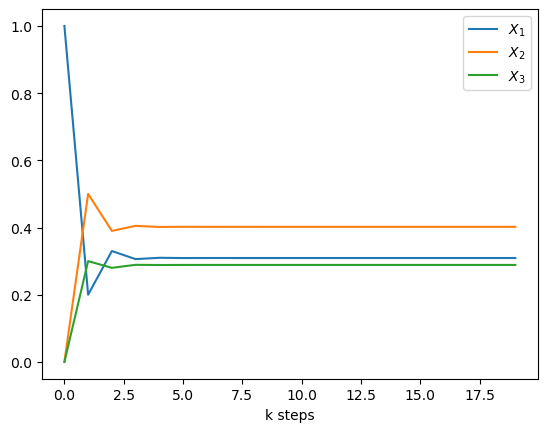

In [55]:
states_array = np.array(states)

plt.plot(states_array[:, 0], label=r"$X_1$")
plt.plot(states_array[:, 1], label=r"$X_2$")
plt.plot(states_array[:, 2], label=r"$X_3$")
plt.xlabel("k steps")
plt.legend()

We can see that the state has converged to a stationary distribution. Let $\mathbf{s}_\infty$ be the stationary distribution. We can see that any application of the transition matrix has no effect
$$
    M \mathbf{s}_\infty = \mathbf{s}_\infty
$$
which follows the general eigenvalue formula $A \mathbf{v} = \lambda \mathbf{v}$, where $\lambda=1$ and $\mathbf{s}_\infty$ is the associated eigenvector for eigenvalue $\lambda=1$. Therefore, we can shortcut the repeated linear transformation of the transition matrix by finding the eigenvector of $M$ that corresponds to $\lambda=1$.

Note: since $\mathbf{s}$ represents a distribution, we need to normalize the eigenvector 
$$
    \mathbf{s}_\infty = \dfrac{1}{||\mathbf{v}||_1} \begin{bmatrix} |v_1| \\ |v_2| \\ \vdots \\ |v_n|\end{bmatrix}
$$

In [57]:
eigvals, eigvecs = np.linalg.eig(M)

abs(eigvecs[:, 0]) / np.sum(abs(eigvecs[:, 0]))

array([0.30927835, 0.40206186, 0.28865979])

## Pokemon name markov chain

In [113]:
f = open("../datasets/text_sample/pokemon_names.txt", 'r')

raw = [name[:-1] for name in f.readlines()]
names = ['#' + name + '$' for name in raw]
names

['#Bulbasaur$',
 '#Ivysaur$',
 '#Venusaur$',
 '#Charmander$',
 '#Charmeleon$',
 '#Charizard$',
 '#Squirtle$',
 '#Wartortle$',
 '#Blastoise$',
 '#Caterpie$',
 '#Metapod$',
 '#Butterfree$',
 '#Weedle$',
 '#Kakuna$',
 '#Beedrill$',
 '#Pidgey$',
 '#Pidgeotto$',
 '#Pidgeot$',
 '#Rattata$',
 '#Raticate$',
 '#Spearow$',
 '#Fearow$',
 '#Ekans$',
 '#Arbok$',
 '#Pikachu$',
 '#Raichu$',
 '#Sandshrew$',
 '#Sandslash$',
 '#Nidoran♀$',
 '#Nidorina$',
 '#Nidoqueen$',
 '#Nidoran♂$',
 '#Nidorino$',
 '#Nidoking$',
 '#Clefairy$',
 '#Clefable$',
 '#Vulpix$',
 '#Ninetales$',
 '#Jigglypuff$',
 '#Wigglytuff$',
 '#Zubat$',
 '#Golbat$',
 '#Oddish$',
 '#Gloom$',
 '#Vileplume$',
 '#Paras$',
 '#Parasect$',
 '#Venonat$',
 '#Venomoth$',
 '#Diglett$',
 '#Dugtrio$',
 '#Meowth$',
 '#Persian$',
 '#Psyduck$',
 '#Golduck$',
 '#Mankey$',
 '#Primeape$',
 '#Growlithe$',
 '#Arcanine$',
 '#Poliwag$',
 '#Poliwhirl$',
 '#Poliwrath$',
 '#Abra$',
 '#Kadabra$',
 '#Alakazam$',
 '#Machop$',
 '#Machoke$',
 '#Machamp$',
 '#Bellsprout$

### Build transition matrix

In [136]:
from collections import Counter
counter = Counter(''.join(raw) + '#$')
num_chars = len(counter.keys())

In [137]:
chars2int = dict(zip(counter.keys(), range(num_chars)))
int2chars = list(counter.keys())

int2chars[0], chars2int['B']

('B', 0)

In [138]:
M = np.zeros((num_chars, num_chars)) + 1e-6
M.shape

(63, 63)

In [139]:
for name in names:
    for xj, xi in zip(name, name[1:]):
        # count occurences 
        # M[to, from] += 1
        M[chars2int[xi], chars2int[xj]] += 1

In [140]:
# normalize columns
M = M / M.sum(axis=0)
M

array([[1.66666492e-08, 3.18471274e-09, 2.13675185e-09, ...,
        9.99937004e-07, 5.36585343e-02, 1.58730159e-02],
       [1.66666508e-01, 3.18471274e-09, 4.91452947e-02, ...,
        9.99937004e-07, 9.75609696e-10, 1.58730159e-02],
       [9.99999117e-02, 7.32483961e-02, 8.76068280e-02, ...,
        9.99937004e-07, 9.75609696e-10, 1.58730159e-02],
       ...,
       [1.66666492e-08, 3.18471274e-09, 2.13675185e-09, ...,
        9.99937004e-07, 9.75609696e-10, 1.58730159e-02],
       [1.66666492e-08, 3.18471274e-09, 2.13675185e-09, ...,
        9.99937004e-07, 9.75609696e-10, 1.58730159e-02],
       [1.66666492e-08, 6.68789707e-02, 1.17521354e-01, ...,
        9.99937004e-07, 9.75609696e-10, 1.58730159e-02]])

In [141]:
M.sum(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
s0 = np.zeros(num_chars)
s0[chars2int['#']] = 1 # initial state 
s0

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])

### Perform state transitions

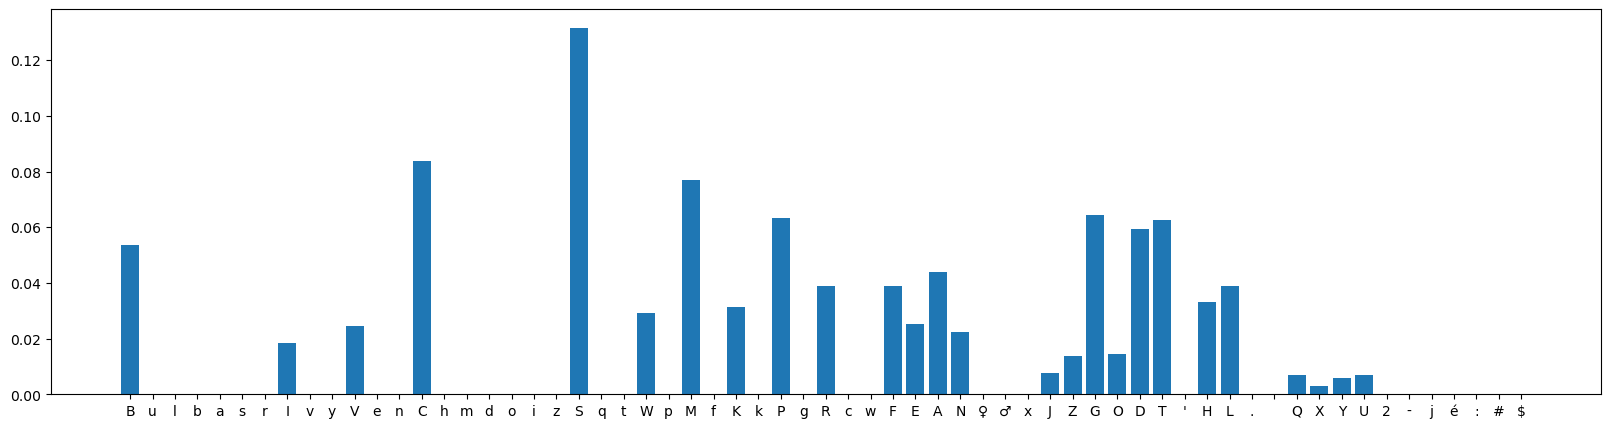

In [148]:
s1 = M @ s0

plt.figure(figsize=(20, 5))
plt.bar(int2chars, s1)
plt.show()

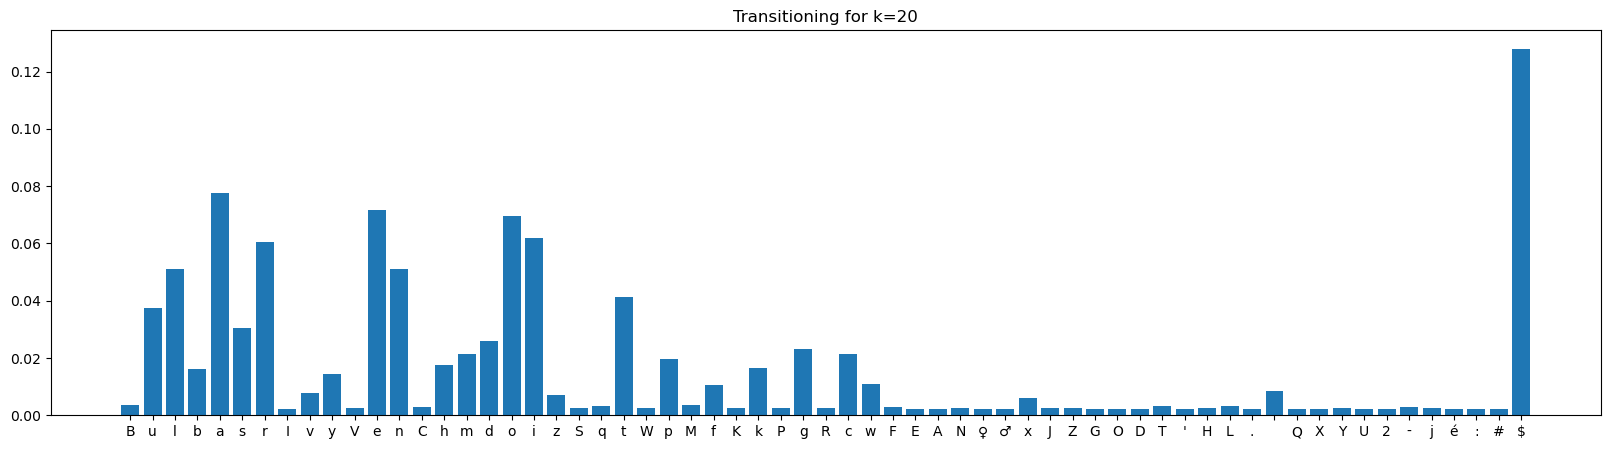

In [152]:
k = 20
sk = s0
states = []

for _ in range(k):
    states.append(sk)
    sk = M @ sk

plt.figure(figsize=(20, 5))
plt.bar(int2chars, sk)
plt.title(f"Transitioning for {k=}")
plt.show()

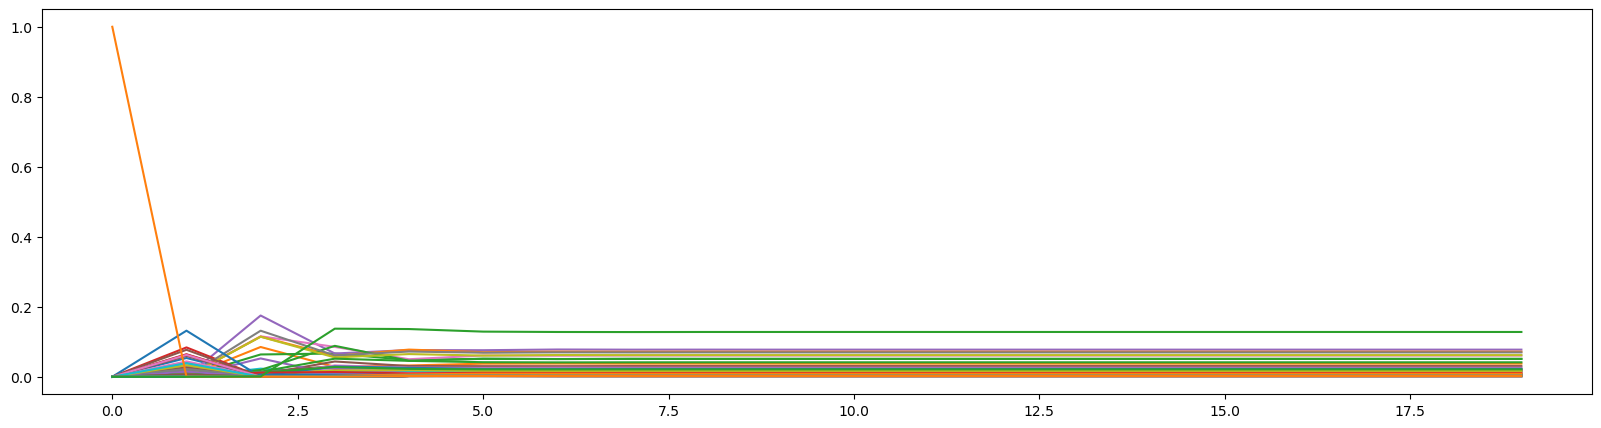

In [155]:
plt.figure(figsize=(20, 5))
plt.plot(states)
plt.show()

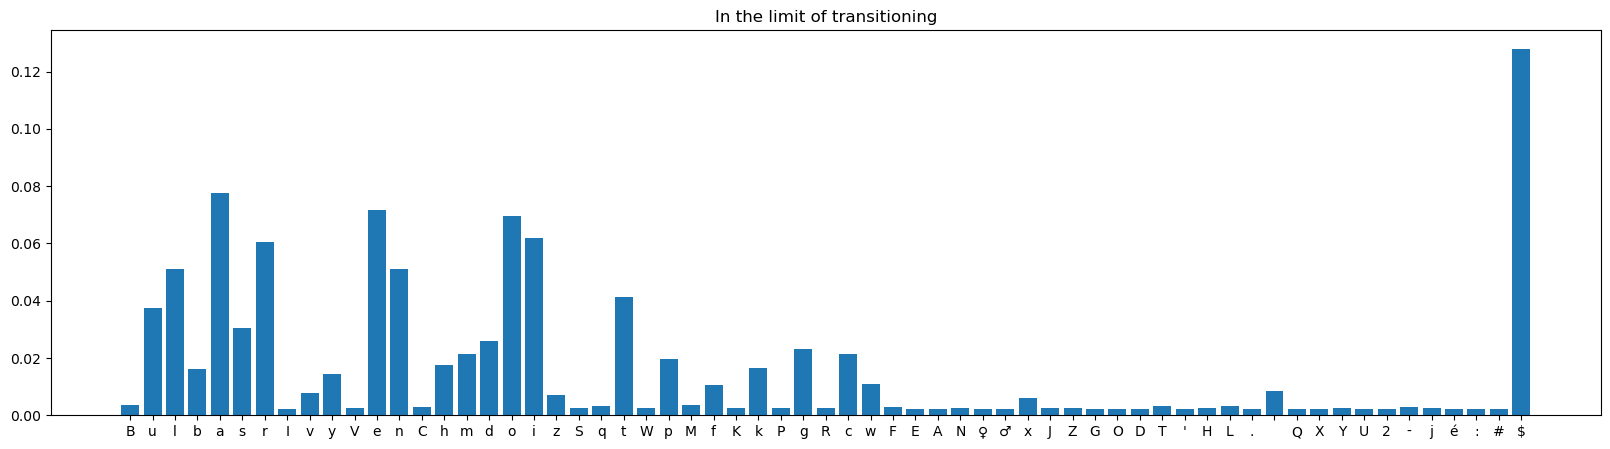

In [159]:
eigvals, eigvecs = np.linalg.eig(M)

s_inf = abs(eigvecs[:, 0]) / np.sum(abs(eigvecs[:, 0]))

plt.figure(figsize=(20, 5))
plt.bar(int2chars, s_inf)
plt.title(f"In the limit of transitioning")
plt.show()

In [201]:
k = 10
sk = s0
new_name = []

for _ in range(k):
    sample = np.random.choice(int2chars, 1, p=sk)[0]
    new_name.append(sample)
    if sample == '$': break
    sk = M @ sk

''.join(new_name)

'#Rrsd♂Seko'

### Pokemon name generator function

In [295]:
def generate_pokemon_name(chars2int, int2chars, max_len=10):
    
    new_name = []
    
    sk = np.zeros(num_chars)
    sk[chars2int['#']] = 1 # initial state 

    for _ in range(max_len):
        sample = np.random.choice(int2chars, 1, p=sk)[0]
        if sample == '$': break
        new_name.append(sample)
        sk = M @ sk

    return ''.join(new_name[1:])

for _ in range(10):
    print(generate_pokemon_name(chars2int, int2chars, max_len=10))

TrpiéuK
Pre
Qhvvse
Bluie'lia
Bhauopabn
Pat
Gwioukh
Saol
Alomo♂ma
KrmlUa


### Using converged state as distribution

In [364]:
def generate_pokemon_name_converged(s_inf, int2chars, max_len=10):
    
    new_name = []

    for _ in range(max_len):
        sample = np.random.choice(int2chars, 1, p=s_inf)[0]
        if sample == '$': break
        new_name.append(sample)

    return ''.join(new_name[1:])

eigvals, eigvecs = np.linalg.eig(M)

s_inf = abs(eigvecs[:, 0]) / np.sum(abs(eigvecs[:, 0]))

for _ in range(10):
    print(generate_pokemon_name_converged(s_inf, int2chars, max_len=10))

yi
Bsly
apqo
nkNomtiae
ds

a
ju
atdie
r
